<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [ ]:
#Importation de la librairie Pandas
import pandas as pd

In [ ]:
import plotly.express as px

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [ ]:
#Lien permettant d'accéder à mon Google Drive ou sont stocker mes fichiers
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Importation du fichier web.xlsx
web = pd.read_excel('/content/drive/MyDrive/Projet_6_Data/web.xlsx')
#Importation du fichier erp.xlsx
erp = pd.read_excel('/content/drive/MyDrive/Projet_6_Data/erp.xlsx')
#Importation du fichier liaison.xlsx
liaison = pd.read_excel('/content/drive/MyDrive/Projet_6_Data/liaison.xlsx')

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning:

Unknown extension is not supported and will be removed

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning:

Unknown extension is not supported and will be removed

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning:

Unknown extension is not supported and will be removed



In [ ]:
#Trouver dans Google l'instruction permettant d'afficher toutes les colonnes d'un dataframe
#Saisir dans Google les mots clés "display all columns dataframe Pandas" par exemple.
#Dans les résultats de la recherche, privilégier les solutions provenant de Stack Overflow ou Medium
pd.set_option('display.max_columns', None)

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier erp.xlsx</h3>
</div>

In [ ]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(erp.shape[0]))
print("Le tableau comporte {} colonne(s)".format(erp.shape[1]))

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 6 colonne(s)


In [ ]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
erp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    int64  
 1   onsale_web      825 non-null    int64  
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   stock_status    825 non-null    object 
 5   purchase_price  825 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 38.8+ KB


In [ ]:
#Afficher les 5 premières lignes de la table
erp.head(5)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


In [ ]:
#Vérifier si il y a des lignes en doublon dans la colonne product_id
print(f"Nombre de doublons dans la colonne 'product_id': {erp.duplicated(subset='product_id').sum()}")

# Afficher les lignes en doublon
display(erp[erp.duplicated(subset='product_id', keep=False)].sort_values(by='product_id'))

Nombre de doublons dans la colonne 'product_id': 0


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price


Nous ne trouvons pas de doublon pour ce fichier. Utilisation de display plutot que print pour conserver l'apparence d'un tableau


In [ ]:
#Afficher les valeurs distinctes de la colonne stock_status
erp['stock_status'].unique()
#À quelle(s) autre(s) colonne(s) sont-elles liées ?


array(['instock', 'outofstock'], dtype=object)

Ces valeurs "instock" et "Outofstock" sont liée aux valeurs de la colonnes "Stock_quantity" qui elles donnent le nombre de produits en stock

In [ ]:
#Création d'une colonne "stock_status_2"
#La valeur de cette deuxième colonne sera fonction de la valeur dans la colonne "stock_quantity"
#Si la valeur de la colonne "stock_quantity" est nulle, renseigner "outofstock" sinon mettre "instock"
erp['stock_status_2'] = erp['stock_quantity'].apply(lambda x: 'outofstock' if x == 0 else 'instock')

In [ ]:
#Vérifions que les 2 colonnes sont identiques:
#Les 2 colonnes sont strictement identiques si les valeurs de chaque ligne sont strictement identiques 2 à 2
#La comparaison de 2 colonnes peut se réaliser simplement avec l'instruction ci-dessous:
erp["stock_status"] == erp["stock_status_2"]
#Le résultat est l'affichage de True ou False pour chacune des lignes du dataset
#C'est un bon début, mais difficile à exploiter

,0
0,True
1,True
2,True
3,True
4,False
...,...
820,True
821,True
822,True
823,True


In [ ]:
#Mais il est possible de synthétiser ce résultat en effectuant la somme de cette colonne:
#True vaut 1 et False 0
#Nous devrions obtenir la somme de 824 qui correspond au nombre de lignes dans ce dataset

comparison = (erp["stock_status"] == erp["stock_status_2"])
num_true = comparison.sum()
num_false = len(comparison) - num_true
staut_2_sum = (num_true * 1) + (num_false * 2)
print(f"la somme de la colonne est de : {staut_2_sum}")


la somme de la colonne est de : 829


In [ ]:
#Si les colonnes ne sont absolument pas identiques ligne à ligne alors identifier la ligne en écart
##Dans ce cas je vous donne ce lien pour apprendre à réaliser des filtres dans Pandas:
##https://bitbucket.org/hrojas/learn-pandas/src/master/
##Lesson 3

display(erp[erp["stock_status"] != erp["stock_status_2"]])

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
4,4039,1,46.0,3,outofstock,23.77,instock
398,4885,1,18.7,0,instock,9.66,outofstock
449,4973,0,10.0,-10,outofstock,4.96,instock
573,5700,1,44.5,-1,outofstock,22.30,instock


Je vais changer les données qui sont incohérente en prenant par ordre de correction :

*   La suppression du caractère "-" pour les produits 4973 et 5700
*   Corriger les incohérences en me basant sur deux données cohérente : pour le produit 4039, C'est bien "Onsale" avec un stock de 3, on corrige donc le statut par "instock", de même pour 4973 et 5700



In [ ]:
#Corriger la ou les données incohérentes
erp.loc[erp['product_id'].isin([4973, 5700]), 'stock_quantity'] = erp.loc[erp['product_id'].isin([4973, 5700]), 'stock_quantity'].abs()
erp.loc[erp['product_id'] == 4885, 'stock_status']='outofstock'
erp.loc[erp['product_id'] == 4973, 'stock_statut']='instock'
erp.loc[erp['product_id'] == 4039, 'stock_status'] = 'instock'
erp.loc[erp['product_id'] == 5700, 'stock_status'] = 'instock'

#Verifier cette correction
erp.loc[erp['product_id'] == 4973, 'stock_status_2'] = 'outofstock'

#Vérification en utilisant le même code que plus haut pour afficher les problèmes
display(erp[erp["stock_status"] != erp["stock_status_2"]])

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2,stock_statut


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1 - Analyse exploratoire de chaque variable du fichier erp.xlsx</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.1 - Analyse de la variable PRIX</h3>
</div>

In [ ]:
###############
## LES PRIX  ##
###############

#Vérification des prix: Y a t-il des prix non renseignés, négatifs ou nuls?
#Afficher le ou les prix non renseignés dans la colonne "price"
print(f"Nombres d'articles avec un prix non renseigné: {erp['price'].isnull().sum()}")

#Afficher le prix minimum de la colonne "price"
print(f"Prix minimum: {erp['price'].min()}")

#Afficher le prix maximum de la colonne "price"
print(f"Prix maximum: {erp['price'].max()}")

#Afficher les prix inférieurs à 0 (qu'est-ce qu'il faut en faire ?)
print(f"Nombres d'articles avec un prix négatif: {erp[erp['price'] < 0].shape[0]}")



Nombres d'articles avec un prix non renseigné: 0
Prix minimum: -20.0
Prix maximum: 225.0
Nombres d'articles avec un prix négatif: 3


In [ ]:
#Afficher les 3 produits avec des valeurs négatives
erp[erp['price'] < 0].head(3)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2,stock_statut
151,4233,0,-20.0,0,outofstock,10.33,outofstock,NaN
469,5017,0,-8.0,0,outofstock,4.34,outofstock,NaN
739,6594,0,-9.1,19,instock,4.61,instock,NaN


In [ ]:
#Il s'agit certainement d'erreur de saisie à corriger en retirant le signe "-"
erp['price'] = erp['price'].abs()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.2 - Analyse de la variable STOCK</h3>
</div>

In [ ]:
#######################
### stock_quantity  ###
#######################

#Vérification de la colonne stock quantity
#Afficher la quantité minimum de la colonne "stock_quantity"
print(f"Quantité minimum en stock: {erp['stock_quantity'].min()}")

#Afficher la quantité maximum de la colonne "stock_quantity"
print(f"Quantité maximum en stock: {erp['stock_quantity'].max()}")

#Afficher les stocks inférieurs à 0 (qu'est-ce qu'il faut en faire ?)
print(f"Nombre d'articles avec un stock négatif: {erp[erp['stock_quantity'] < 0].shape[0]}")

Quantité minimum en stock: 0
Quantité maximum en stock: 145
Nombre d'articles avec un stock négatif: 0


Nous avons deja corrigé les stocks négatifs lors de la correction des données incohérentes

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.3 - Analyse de la variable ONSALE_WEB</h3>
</div>

In [ ]:
#Vérification de la colonne onsale_web et des valeurs qu'elle contient. Que signifient-elles?
print(erp['onsale_web'].unique())


[1 0]


Il s'agit de valeurs Boléennes 0 traduisant l'absence de vente en ligne et 1 qu'il est possible d'acheter le produit sur le site internet

#Quelles sont les colonnes à conserver selon vous?
Toute les colonnes hormis celle que nous avons crée (stock_statut_2) sont imporantes

*   **product_id** permet d'identifier le produit
*   **onsale_web** permet de savoir si le produit est disposible à la vente en ligne
*   **price** pour connaitre le prix du produit
*   **stock_quantity** pour connaitre notre stock pour chaque produit
* **stock_statut** permettra de voir rapidement les produits qui ne sont plus en stock
* **purchase_pric**e pour calculer notre marge entre le cout d'achat via nos fournisseur et la vente des produits






In [ ]:
#Supprimer la colonne comportant le libellé "stock_status_2" car elle est redondante
#avec la colonne "stock_status".
erp = erp.drop(columns=['stock_status_2'])


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.4 - Analyse de la variable prix d'achat</h3>
</div>

In [ ]:
######################
##   prix d'achat   ##
######################

#Vérification de la colonne purchase_price :
#Afficher le ou les prix non renseignés dans la colonne "purchase_price"
print(f"Nombres d'articles avec un prix d'achat non renseigné: {erp['purchase_price'].isnull().sum()}")

#Afficher le prix minimum de la colonne "purchase_price"
print(f"Prix d'achat minimum: {erp['purchase_price'].min()}")
#Afficher le prix maximum de la colonne "purchase_price"
print(f"Prix d'achat maximum: {erp['purchase_price'].max()}")


Nombres d'articles avec un prix d'achat non renseigné: 0
Prix d'achat minimum: 2.74
Prix d'achat maximum: 137.81


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier web.xlsx</h3>
</div>


In [ ]:
#Dimension du dataset

#Nombre d'observations
print(f"Le tableau comporte {web.shape[0]} ligne(s)")
#Nombre de caractéristiques
print(f"Le tableau comporte {web.shape[1]} colonne(s)")

Le tableau comporte 1513 ligne(s)
Le tableau comporte 29 colonne(s)


In [ ]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
web.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   sku                    1428 non-null   object        
 1   virtual                1513 non-null   int64         
 2   downloadable           1513 non-null   int64         
 3   rating_count           1513 non-null   int64         
 4   average_rating         1430 non-null   float64       
 5   total_sales            1430 non-null   float64       
 6   tax_status             716 non-null    object        
 7   tax_class              0 non-null      float64       
 8   post_author            1430 non-null   float64       
 9   post_date              1430 non-null   datetime64[ns]
 10  post_date_gmt          1430 non-null   datetime64[ns]
 11  post_content           0 non-null      float64       
 12  product_type           1429 non-null   object        
 13  pos

In [ ]:
#Selon vous, quelles sont les colonnes à conserver ?
web.describe()

,virtual,downloadable,rating_count,average_rating,total_sales,tax_class,post_author,post_date,post_date_gmt,post_content,post_password,post_modified,post_modified_gmt,post_content_filtered,post_parent,menu_order,comment_count
count,1513.0,1513.0,1513.0,1430.0,1430.000000,0.0,1430.000000,1430,1430,0.0,0.0,1430,1430,0.0,1430.0,1430.0,1430.0
mean,0.0,0.0,0.0,0.0,8.223077,NaN,1.998601,2018-08-22 03:22:17.090909184,2018-08-22 01:53:30.097902080,NaN,NaN,2020-06-20 13:59:29.781818112,2020-06-20 12:06:02.509090816,NaN,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,-56.000000,NaN,1.000000,2018-02-08 12:58:52,2018-02-08 11:58:52,NaN,NaN,2018-02-20 15:19:23,2018-02-20 14:19:23,NaN,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,5.000000,NaN,2.000000,2018-02-27 20:01:12.500000,2018-02-27 19:01:12.500000,NaN,NaN,2020-06-18 10:45:05.249999872,2020-06-18 08:45:05.249999872,NaN,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,8.000000,NaN,2.000000,2018-04-19 14:56:05,2018-04-19 12:56:05,NaN,NaN,2020-08-04 09:30:06,2020-08-04 07:30:06,NaN,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,11.000000,NaN,2.000000,2019-01-31 14:35:47,2019-01-31 13:35:47,NaN,NaN,2020-08-25 10:32:32,2020-08-25 08:32:32,NaN,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,122.000000,NaN,2.000000,2020-07-20 11:00:00,2020-07-20 09:00:00,NaN,NaN,2020-08-27 18:55:03,2020-08-27 16:55:03,NaN,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,6.721899,NaN,0.037385,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0


#Selon vous, quelles sont les colonnes à conserver ?
Je vais prendre la question à l'envers dans un premier temps pour mon raisonnement, en me demandant quelles sont les colonnes que je peux supprimer :
* Je constate plusieurs colonnes dont la seule valeur est "0"
* Ainsi que plusieurs colonnes avec de nombreuse valeurs manquantes
* Je n'ai enfin pas la nécessité des dates vu que l'export à deja été fait pour le mois d'Octobre

In [ ]:
#Si vous avez défini des colonnes à supprimer, effectuer l'opération
#Suppression colonnes dont toutes les lignes sont égales à 0
web = web.drop(web.loc[:, (web == 0).all(axis='rows')], axis='columns')

#Suppression colonnes dont toutes les lignes sont vides
web = web.dropna(axis='columns', how='all')

#Suppression des colonnes non pertinante
web = web.drop(columns=['post_date', 'post_date_gmt', 'post_modified', 'post_modified_gmt',
                        'post_excerpt','post_status','comment_status','ping_status','post_name','guid','post_mime_type'])


#Verification des correction
web.describe()

,average_rating,total_sales,post_author,post_parent,menu_order,comment_count
count,1430.0,1430.000000,1430.000000,1430.0,1430.0,1430.0
mean,0.0,8.223077,1.998601,0.0,0.0,0.0
std,0.0,6.721899,0.037385,0.0,0.0,0.0
min,0.0,-56.000000,1.000000,0.0,0.0,0.0
25%,0.0,5.000000,2.000000,0.0,0.0,0.0
50%,0.0,8.000000,2.000000,0.0,0.0,0.0
75%,0.0,11.000000,2.000000,0.0,0.0,0.0
max,0.0,122.000000,2.000000,0.0,0.0,0.0


Je remarque encore 4 colonnes comportent 1430 fois la valeur 0. Il serai interessent de vérifier ce que comprend les autres lignes


In [ ]:
#Décompte des valeurs autre que 0 pour ces 4 colonnes
web[['average_rating', 'post_parent', 'menu_order', 'comment_count']].value_counts(dropna=False)

,,,,count
average_rating,post_parent,menu_order,comment_count,
0.0,0.0,0.0,0.0,1430
NaN,NaN,NaN,NaN,83


Ces 4 colonnes n'ont donc pas de valeur interessantent vu qu'il ne s'agit que de 0 de données manquantes. Nous pouvons donc les supprimer

In [ ]:
web = web.drop(['average_rating', 'post_parent','menu_order', 'comment_count'], axis='columns')
web.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sku           1428 non-null   object 
 1   total_sales   1430 non-null   float64
 2   tax_status    716 non-null    object 
 3   post_author   1430 non-null   float64
 4   product_type  1429 non-null   object 
 5   post_title    1430 non-null   object 
 6   post_type     1430 non-null   object 
dtypes: float64(2), object(5)
memory usage: 82.9+ KB


In [ ]:
#Visualisation des valeurs de la colonne sku
#Quelles sont les valeurs qui ne semblent pas respecter la régle de codification?
web["sku_length"] = web["sku"].str.len()
anomalies = web[web["sku_length"].isin([web["sku_length"].min(), web["sku_length"].max()])]
print(anomalies)



                      sku  total_sales tax_status  post_author product_type  \
272               13127-1          4.0    taxable          2.0          Vin   
842   bon-cadeau-25-euros          7.0        NaN          1.0        Autre   
1117              13127-1          4.0        NaN          2.0          Vin   
1387  bon-cadeau-25-euros          7.0    taxable          1.0          NaN   

                                        post_title   post_type  sku_length  
272   Clos du Mont-Olivet Châteauneuf-du-Pape 2007     product         7.0  
842                              Bon cadeau de 25€  attachment        19.0  
1117  Clos du Mont-Olivet Châteauneuf-du-Pape 2007  attachment         7.0  
1387                             Bon cadeau de 25€     product        19.0  


#Si vous avez identifié des codes articles ne respectant pas la régle de codification, consultez-les

Deux colonnes ne sont pas convenablement codidiés
 "13127-1" et "bon-cadeau-25-euros" que je souhaite conserver en l'état


In [ ]:
#Identifier les lignes sans code article
display(web[web['sku'].isnull()])

,sku,total_sales,tax_status,post_author,product_type,post_title,post_type,sku_length
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
1384,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1432,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1445,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#Pour les codes articles identifiés, réaliser une analyse et définir l'action à entreprendre
sku_vide = web["sku"].isna() | (web["sku"].str.strip() == "")
autres_vides = web.loc[sku_vide].drop(columns=["sku"]).isna().all(axis=1)
problemes = web.loc[sku_vide & ~autres_vides]
print(problemes)

      sku  total_sales tax_status  post_author product_type  \
1084  NaN        -56.0    taxable          2.0          Vin   
1087  NaN        -17.0    taxable          2.0          Vin   

                                           post_title post_type  sku_length  
1084  Pierre Jean Villa Condrieu Jardin Suspendu 2018   product         NaN  
1087       Pierre Jean Villa Côte Rôtie Fongeant 2017   product         NaN  


Ce sont deux lignes avec des valeurs de ventes négatives en plus de ne pas avoir de SKU, nous allons donc les supprimer

In [ ]:
#La clé pour chaque ligne est-elle unique? autrement dit, y a-t-il des doublons?
compte = web["sku"].value_counts()
doublons_compte = compte[compte > 1]
print(doublons_compte)

sku
14569    2
11862    2
16057    2
14692    2
16295    2
        ..
15575    2
12869    2
15526    2
16269    2
16585    2
Name: count, Length: 714, dtype: int64


Nous avons donc des doublons, il faudra vérifier s'il y a une grande différence entre la ligne et son doublon pour pouvoir le supprimer si besoin






In [ ]:
import numpy as np
# Sélection aléatoire d'une ligne
random_index = np.random.randint(0, len(liaison['product_id']))
# Sélection SKU à partir de l'index de la ligne aléatoire
random_sku = web['sku'].iloc[random_index]
# Affichage des deux lignes en doublons
web.loc[web['sku'] == random_sku]

,sku,total_sales,tax_status,post_author,product_type,post_title,post_type,sku_length
242,15706,9.0,NaN,2.0,Vin,Decelle-Villa Marsannay Les Longeroies 2015,attachment,NaN
1484,15706,9.0,taxable,2.0,Vin,Decelle-Villa Marsannay Les Longeroies 2015,product,NaN


Nous allons conserver les lignes pour laquelle la colonne post_type est noté "product"

In [ ]:
web = web.loc[web['post_type'] != 'attachment'].copy()

In [ ]:
#Les lignes sans code article semblent être toutes non renseignées
#Pour s'en assurer, réaliser les étapes suivantes:
#1 - Créer un dataframe avec uniquement les lignes sans code article
df_sku_null = web[web['sku'].isnull()]

#2 - Utiliser la fonction df.info() sur ce nouveau dataframe pour observer le nombre de valeurs renseignées dans chacune des colonnes
print("Information sur les lignes sans SKU:")
df_sku_null.info()

#3 - Que constatez-vous?
print("\nVisualisation des lignes sans SKU:")
display(df_sku_null)

Information sur les lignes sans SKU:
<class 'pandas.core.frame.DataFrame'>
Index: 85 entries, 8 to 1457
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sku           0 non-null      object 
 1   total_sales   2 non-null      float64
 2   tax_status    2 non-null      object 
 3   post_author   2 non-null      float64
 4   product_type  2 non-null      object 
 5   post_title    2 non-null      object 
 6   post_type     2 non-null      object 
 7   sku_length    0 non-null      float64
dtypes: float64(3), object(5)
memory usage: 6.0+ KB

Visualisation des lignes sans SKU:


,sku,total_sales,tax_status,post_author,product_type,post_title,post_type,sku_length
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
1384,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1432,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1445,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Deux lignes sont remplit mais n'ont pas de sku, les autres données sans sku sont entièrement vides

In [ ]:
#Suppression de toute les lignes ou le sku est vide
web = web.dropna(subset=['sku'])
web.shape

(714, 8)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire du fichier liaison.xlsx</h3>
</div>

In [ ]:
#Dimension du dataset
#Nombre d'observations
#Nombre de caractéristiques
liaison.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_web      734 non-null    object
 1   product_id  825 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 13.0+ KB


In [ ]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
liaison.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_web      734 non-null    object
 1   product_id  825 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 13.0+ KB


In [ ]:
#Les valeurs de la colonne "product_id" sont-elles toutes uniques?
print(f"La colonne 'product_id' contient uniquement des valeurs uniques: {liaison['product_id'].is_unique}")

La colonne 'product_id' contient uniquement des valeurs uniques: True


In [ ]:
#Les valeurs de la colonne "id_web" sont-elles toutes uniques?
print(f"La colonne 'id_web' contient uniquement des valeurs uniques: {liaison['id_web'].is_unique}")

La colonne 'id_web' contient uniquement des valeurs uniques: False


In [ ]:
#Avons-nous des articles sans correspondance?
print(f"Nombre d'articles sans correspondance (id_web manquant): {liaison['id_web'].isnull().sum()}")

Nombre d'articles sans correspondance (id_web manquant): 91


In [ ]:
#Nous pouvons donc les supprimer
liaison = liaison.dropna(subset=['id_web'])

In [ ]:
#Revérifier si les valeurs de la colonne "id_web" sont-elles toutes uniques?
print(f"La colonne 'id_web' contient uniquement des valeurs uniques: {liaison['id_web'].is_unique}")

La colonne 'id_web' contient uniquement des valeurs uniques: True


id_web, correspond à notre 'sku' dans le df web, nous allons donc le renommer pour la suite des traitement

In [ ]:
liaison = liaison.rename(columns={'id_web': 'sku'})

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.1 - Jonction du fichier df_erp et df_liaison</h3>
</div>

In [ ]:
#Fusion des fichiers erp et liaison
df_final = pd.merge(erp, liaison, on='product_id', how='left')
df_final.shape


(825, 8)

In [ ]:
#Y a t-il des lignes ne "matchant" pas entre les 2 fichiers?
df_final.isna().sum()
# Lignes qui n'ont pas matché


,0
product_id,0
onsale_web,0
price,0
stock_quantity,0
stock_status,0
purchase_price,0
stock_statut,824
sku,91


Nous retrouvons les 91 lignes du fichier d'origine

In [ ]:
df_final = df_final.loc[~df_final['sku'].isna()].copy().reset_index(drop=True)
df_final.shape

(734, 8)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.2 - Jonction du fichier df_merge et df_web</h3>
</div>

In [ ]:
#Fusionner les datasets df_merge et web
df_final = df_final.loc[~df_final['sku'].isna()].copy().reset_index(drop=True)
df_final = pd.merge((df_final), (web), on = ['sku'], how = 'left')
df_final.shape

(734, 15)

In [ ]:
#Avons-nous des lignes sans correspondance?
df_final.isna().sum()

,0
product_id,0
onsale_web,0
price,0
stock_quantity,0
stock_status,0
purchase_price,0
stock_statut,734
sku,0
total_sales,20
tax_status,20


In [ ]:
#Voir les 20 produits total_sales en question
df_final.loc[df_final['total_sales'].isna()].head(20)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_statut,sku,total_sales,tax_status,post_author,product_type,post_title,post_type,sku_length
185,4289,0,22.8,0,outofstock,11.90,NaN,13771,NaN,NaN,NaN,NaN,NaN,NaN,NaN
227,4568,0,21.5,0,outofstock,11.22,NaN,15065,NaN,NaN,NaN,NaN,NaN,NaN,NaN
230,4584,0,32.3,0,outofstock,17.36,NaN,14785,NaN,NaN,NaN,NaN,NaN,NaN,NaN
334,4741,0,12.4,0,outofstock,6.66,NaN,12601,NaN,NaN,NaN,NaN,NaN,NaN,NaN
368,4864,0,8.3,0,outofstock,9.99,NaN,15154,NaN,NaN,NaN,NaN,NaN,NaN,NaN
371,4869,0,17.2,0,outofstock,9.33,NaN,14360,NaN,NaN,NaN,NaN,NaN,NaN,NaN
399,4921,0,13.8,0,outofstock,7.13,NaN,15608,NaN,NaN,NaN,NaN,NaN,NaN,NaN
400,4922,0,21.5,0,outofstock,10.55,NaN,15586,NaN,NaN,NaN,NaN,NaN,NaN,NaN
443,5018,0,15.4,0,outofstock,7.72,NaN,15272,NaN,NaN,NaN,NaN,NaN,NaN,NaN
445,5021,0,17.1,0,outofstock,8.92,NaN,15630,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Il reste 20 produits qui n'ont pas de valeur, nous pouvons également les supprimer

In [ ]:
df_final = df_final.loc[~df_final['total_sales'].isna()].copy().reset_index(drop=True)
df_final.shape

(714, 15)

In [ ]:
#Verifier que le reste des produits ont des ventes
(df_final['total_sales']==0).any()

np.True_

In [ ]:
#Affichier les produits qui n'ont pas de vente
df_final.loc[df_final['total_sales']==0]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_statut,sku,total_sales,tax_status,post_author,product_type,post_title,post_type,sku_length
2,3850,1,20.80,0,outofstock,10.64,NaN,15300,0.0,taxable,2.0,Vin,Pierre Jean Villa Crozes-Hermitage Accroche Co...,product,NaN
8,4043,1,60.00,0,outofstock,29.45,NaN,14980,0.0,taxable,2.0,Vin,Pierre Gaillard Côte Rôtie Esprit de Blonde 2017,product,NaN
11,4047,1,18.30,0,outofstock,9.93,NaN,14977,0.0,taxable,2.0,Vin,Pierre Gaillard Côtes-du-Rhône Blanc Les Gendr...,product,NaN
15,4051,1,7.70,0,outofstock,4.14,NaN,16045,0.0,taxable,2.0,Vin,Jeanne Gaillard IGP Collines Rhodaniennes Syra...,product,NaN
16,4052,1,33.70,0,outofstock,18.11,NaN,16030,0.0,taxable,2.0,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape Blanc ...,product,NaN
27,4065,1,19.50,0,outofstock,9.67,NaN,15022,0.0,taxable,2.0,Vin,Oratoire Saint Martin Cairanne Rouge Les Douye...,product,NaN
41,4079,1,37.00,0,outofstock,19.50,NaN,13078,0.0,taxable,2.0,Vin,Le Vieux Donjon Châteauneuf-du-Pape 2013,product,NaN
54,4100,1,15.80,0,outofstock,8.57,NaN,13416,0.0,taxable,2.0,Vin,Emile Boeckel Gewurztraminer Grand Cru Zotzenb...,product,NaN
67,4138,1,25.70,0,outofstock,13.01,NaN,15341,0.0,taxable,2.0,Vin,Zind-Humbrecht Zind 2017,product,NaN
116,4196,1,27.20,0,outofstock,14.05,NaN,13032,0.0,taxable,2.0,Vin,Château de La Liquière Faugères Tucade 2015,product,NaN


Je remarque que pour plusieurs cas, je n'ai pas de vente et pas de stock, je vais donc supprimer ces lignes également

In [ ]:
df_final = df_final.loc[~((df_final['total_sales'] == 0) & (df_final['stock_quantity'] == 0))].copy()

In [ ]:
#Vérifions maintenant s'il y a eu des ventes alors que nous n'avions pas de stock
df_final[(df_final['total_sales'] > 0) & (df_final['stock_quantity'] == 0)]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_statut,sku,total_sales,tax_status,post_author,product_type,post_title,post_type,sku_length
103,4179,1,24.00,0,outofstock,13.02,NaN,16166,6.0,taxable,2.0,Vin,Domaine de l'Hortus Pic Saint-Loup La Grande C...,product,NaN
149,4241,1,8.90,0,outofstock,4.37,NaN,14725,15.0,taxable,2.0,Vin,Parcé Frères IGP Côtes Catalanes Hommage à Fer...,product,NaN
159,4256,1,24.40,0,outofstock,12.61,NaN,14253,9.0,taxable,2.0,Vin,Domaine Huet Vouvray Haut-Lieu Sec 2017,product,NaN
174,4274,1,12.90,0,outofstock,6.33,NaN,12942,8.0,taxable,2.0,Vin,Domaine Sérol Vin Mousseux Rosé Turbullent Mét...,product,NaN
180,4283,1,27.00,0,outofstock,13.25,NaN,16154,8.0,taxable,2.0,Vin,Château de Cazeneuve Pic Saint-Loup Le Roc Des...,product,NaN
199,4352,1,225.00,0,outofstock,137.81,NaN,15940,11.0,taxable,2.0,Champagne,Champagne Egly-Ouriet Grand Cru Millésimé 2008,product,NaN
242,4612,1,20.60,0,outofstock,10.22,NaN,15038,5.0,taxable,2.0,Vin,Gilbert Picq Chablis Vieilles Vignes 2017,product,NaN
263,4636,1,50.00,0,outofstock,25.58,NaN,2361,4.0,taxable,2.0,Vin,Marcel Windholtz Eau de Vie de Framboise d'Alsace,product,NaN
304,4706,1,16.80,0,outofstock,8.68,NaN,15349,10.0,taxable,2.0,Vin,Albert Mann Muscat 2018,product,NaN
321,4726,1,12.70,0,outofstock,6.82,NaN,14950,22.0,taxable,2.0,Vin,François Baur Pinot Noir Schlittweg 2017,product,NaN


J'en deduis que stock_quantity est mon stock final après vente

In [ ]:
#Compter le nombre de produits restant
df_final.shape

(692, 15)

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse univariée des prix</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1 - Exploration par la visualisation de données</h3>
</div>

In [ ]:
#Création d'une boîte à moustache de la répartition des prix grâce à Pandas
fig = px.box(df_final, y='price', title='Répartition des prix')
fig.show()

In [ ]:
#Autre méthode avec plotly express
import plotly.express as px

fig = px.histogram(df_final, x="price", nbins=30, title="Répartition des prix")
fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2 - Exploration par l'utilisation de méthodes statistiques</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.1 - Identification par le Z-index</h3>
</div>

In [ ]:
#Calculer la moyenne du prix
prix_moyen = df_final['price'].mean()
print(f"Moyenne du prix: {prix_moyen:.2f} €")

#Calculer l'écart-type du prix
ecart_type = df_final['price'].std()
print(f"Écart-type du prix: {ecart_type:.2f} €")

#Calculer le Z-score
df_final['price_zscore'] = (df_final['price'] - prix_moyen) / ecart_type
print("\nPremiers Z-scores des prix:")
display(df_final[['price', 'price_zscore']].head())

Moyenne du prix: 32.36 €
Écart-type du prix: 27.85 €

Premiers Z-scores des prix:


,price,price_zscore
0,24.2,-0.293104
1,34.3,0.069599
3,14.1,-0.655806
4,46.0,0.489759
5,34.3,0.069599


In [ ]:
#Quel est le seuil prix dont le z-score est supérieur à 3?
seuil_prix = 3
seuil_z = prix_moyen + seuil_prix * ecart_type
print(f"Le seuil prix pour un z-score supérieur à {seuil_prix} est: {seuil_z:.2f} €")

Le seuil prix pour un z-score supérieur à 3 est: 115.90 €


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.2 - Identification par l'intervalle interquartile</h3>
</div>

In [ ]:
#Utilisation de la fonction "describe" de Pandas pour l'étude des mesures de dispersion
display(df_final['price'].describe())

,price
count,692.000000
mean,32.361922
std,27.846518
min,5.200000
25%,13.975000
50%,23.400000
75%,42.025000
max,225.000000


In [ ]:
#Définir un seuil pour les articles "outliers" en prix
Q1 = df_final['price'].quantile(0.25)
Q3 = df_final['price'].quantile(0.75)
IQR = Q3 - Q1

seuil_supperieur = Q3 + 1.5 * IQR
seuil_inferieur = Q1 - 1.5 * IQR

print(f"Seuil supérieur pour les outliers (prix): {seuil_supperieur:.2f} €")
print(f"Seuil inférieur pour les outliers (prix): {seuil_inferieur:.2f} €")

Seuil supérieur pour les outliers (prix): 84.10 €
Seuil inférieur pour les outliers (prix): -28.10 €


In [ ]:
#Définir le nombre d'articles et la proportion de l'ensemble du catalogue "outliers"
outliers_price = df_final[(df_final['price'] > seuil_supperieur) | (df_final['price'] < seuil_inferieur)]

nombre_outliers = outliers_price.shape[0]
proportion_outliers = (nombre_outliers / df_final.shape[0]) * 100

print(f"Nombre d'articles outliers en prix: {nombre_outliers}")
print(f"Proportion d'articles outliers en prix: {proportion_outliers:.2f} %")

display(outliers_price[['product_id', 'sku', 'price']])

Nombre d'articles outliers en prix: 31
Proportion d'articles outliers en prix: 4.48 %


,product_id,sku,price
63,4115,15382,100.0
65,4132,11668,88.4
199,4352,15940,225.0
205,4359,13853,85.6
218,4402,3510,176.0
219,4404,3507,108.5
221,4406,7819,157.0
222,4407,3509,104.0
227,4582,12857,109.6
380,4903,14805,102.3


In [ ]:
#Selon vous, ces outliers sont-ils justifiés ? Comment le démontrer si cela est possible ?

print("Détail des articles outliers en prix:")
display(outliers_price[['product_id', 'sku', 'price', 'product_type', 'total_sales', 'post_title']])

print("\nDistribution des types de produits pour les outliers:")
display(outliers_price['product_type'].value_counts())

Détail des articles outliers en prix:


,product_id,sku,price,product_type,total_sales,post_title
63,4115,15382,100.0,Vin,1.0,Zind-Humbrecht Riesling Grand Cru Rangen De Th...
65,4132,11668,88.4,Vin,5.0,Zind-Humbrecht Pinot Gris Grand Cru Rangen De ...
199,4352,15940,225.0,Champagne,11.0,Champagne Egly-Ouriet Grand Cru Millésimé 2008
205,4359,13853,85.6,Champagne,7.0,Champagne Larmandier-Bernier Grand Cru Les Che...
218,4402,3510,176.0,Cognac,3.0,Cognac Frapin VIP XO
219,4404,3507,108.5,Cognac,4.0,Cognac Frapin Château de Fontpinot XO
221,4406,7819,157.0,Cognac,4.0,Cognac Frapin Château de Fontpinot 1989 20 Ans...
222,4407,3509,104.0,Cognac,5.0,Cognac Frapin Cigar Blend
227,4582,12857,109.6,Vin,1.0,Château de Meursault Puligny-Montrachet 1er Cr...
380,4903,14805,102.3,Vin,2.0,Domaine Des Croix Corton Grand Cru Les Grèves ...



Distribution des types de produits pour les outliers:


,count
product_type,
Vin,18
Champagne,6
Cognac,4
Whisky,3


Il s'agit de produit de très haute qualité, ce qui justifie l'écart


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyse univariée du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivariée  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Analyse des ventes en CA</h3>
</div>

In [ ]:
##############################
# Calculer le CA du site web #
##############################

#Créer une colonne calculant le CA par article
df_final['ca_par_article'] = df_final['price'] * df_final['total_sales']

# Calculer la somme de la colonne "ca_par_article"
total_ca = df_final['ca_par_article'].sum()
print(f"Le chiffre d'affaires total du site web est: {total_ca:.2f} €")

#Ce résultat correspond au chiffre d'affaire du site web

Le chiffre d'affaires total du site web est: 143680.10 €


In [ ]:
#Effectuer le tri dans l'ordre décroissant du CA du dataset df_merge
df_final_trie_ca = df_final.sort_values(by='ca_par_article', ascending=False)

#Réinitialiser l'index du dataset par un reset_index
df_final_trie_ca = df_final_trie_ca.reset_index(drop=True)

#Afficher les 20 premiers articles en CA
print("Les 20 premiers articles en CA:")
display(df_final_trie_ca.head(20))

#Graphique en barre des 20 premiers articles avec plotly express
fig_top_20_ca = px.bar(
df_final_trie_ca.head(20),
x='post_title',
y='ca_par_article',
title='Top 20 des articles par Chiffre d\'Affaires',
labels={'post_title': 'Article', 'ca_par_article': 'Chiffre d\'Affaires (€)'},
hover_data=['product_id', 'sku', 'price', 'total_sales']
)
fig_top_20_ca.update_layout(xaxis={'categoryorder':'total descending'})
fig_top_20_ca.show()

Les 20 premiers articles en CA:


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_statut,sku,total_sales,tax_status,post_author,product_type,post_title,post_type,sku_length,price_zscore,ca_par_article
0,4352,1,225.0,0,outofstock,137.81,NaN,15940,11.0,taxable,2.0,Champagne,Champagne Egly-Ouriet Grand Cru Millésimé 2008,product,NaN,6.917852,2475.0
1,5892,1,191.3,98,instock,116.06,NaN,14983,6.0,taxable,2.0,Champagne,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,product,NaN,5.707646,1147.8
2,4353,1,79.5,127,instock,45.91,NaN,12587,14.0,taxable,2.0,Champagne,Champagne Egly-Ouriet Grand Cru Brut Rosé,product,NaN,1.692782,1113.0
3,5826,1,41.2,34,instock,21.71,NaN,15325,20.0,taxable,2.0,Vin,Agnès Levet Côte Rôtie Améthyste 2017,product,NaN,0.317385,824.0
4,6212,1,115.0,16,instock,59.42,NaN,13996,7.0,taxable,2.0,Vin,Domaine des Comtes Lafon Volnay 1er Cru Santen...,product,NaN,2.967627,805.0
5,5026,1,86.8,101,instock,50.13,NaN,13913,9.0,taxable,2.0,Champagne,Champagne Agrapart &amp; Fils Minéral Extra Br...,product,NaN,1.954933,781.2
6,5008,1,105.0,12,instock,56.42,NaN,11602,7.0,taxable,2.0,Vin,Domaine des Comtes Lafon Volnay 1er Cru Santen...,product,NaN,2.608516,735.0
7,5767,1,175.0,12,instock,90.42,NaN,15185,4.0,taxable,2.0,Vin,Camille Giroud Clos de Vougeot 2016,product,NaN,5.122295,700.0
8,6126,1,135.0,138,instock,80.33,NaN,14923,5.0,taxable,2.0,Champagne,Champagne Gosset Célébris Vintage 2007,product,NaN,3.685850,675.0
9,5025,1,112.0,136,instock,68.60,NaN,13914,6.0,taxable,2.0,Champagne,Champagne Agrapart &amp; Fils L'Avizoise Extra...,product,NaN,2.859894,672.0


In [ ]:
# Somme des ventes par type de produit
result = df_final.groupby("product_type", as_index=False)["total_sales"].sum()

# Calcul de la part en %
total = result["total_sales"].sum()
result["percentage"] = (result["total_sales"] / total) * 100

# Tri décroissant
result_sorted = result.sort_values("percentage", ascending=False)

print(result_sorted)

# Somme totale des ventes
total_sales_sum = df_final["total_sales"].sum()

print(total_sales_sum)

    product_type  total_sales  percentage
4            Vin       5456.0   94.986072
0      Champagne        169.0    2.942201
5         Whisky         48.0    0.835655
1         Cognac         35.0    0.609331
3  Huile d'olive         22.0    0.383008
2            Gin         14.0    0.243733
5751.0


In [ ]:
# Créer une colonne calculant la part du CA de la ligne dans le dataset
df_final_trie_ca['share_ca'] = (df_final_trie_ca['ca_par_article'] / total_ca) * 100

# Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_final_trie_ca['cumulative_share_ca'] = df_final_trie_ca['share_ca'].cumsum()

# Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% du CA
articles_80_pourcent_ca = df_final_trie_ca[df_final_trie_ca['cumulative_share_ca'] <= 80]
nombre_articles_80_pourcent_ca = articles_80_pourcent_ca.shape[0]

# Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
proportion_articles_80_pourcent_ca = (nombre_articles_80_pourcent_ca / df_final_trie_ca.shape[0]) * 100

print(f"Nombre d'articles représentant 80% du CA: {nombre_articles_80_pourcent_ca}")
print(f"Proportion de ces articles dans le catalogue entier: {proportion_articles_80_pourcent_ca:.2f} %")

Nombre d'articles représentant 80% du CA: 434
Proportion de ces articles dans le catalogue entier: 62.72 %


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.2 - Analyse des ventes en quantité</h3>
</div>

In [ ]:
#Effectuer le tri dans l'ordre décroissant de quantités vendues du dataset df_merge
df_final_trie_qty = df_final.sort_values(by='total_sales', ascending=False)

#Réinitialiser l'index du dataset par un reset_index
df_final_trie_qty = df_final_trie_qty.reset_index(drop=True)

#Afficher les 20 premiers articles en quantité
print("Les 20 premiers articles en quantité vendue:")
display(df_final_trie_qty.head(20))

#Graphique en barre des 20 premiers articles avec plotly express
fig_top_20_qty = px.bar(
df_final_trie_qty.head(20),
x='post_title',
y='total_sales',
title='Top 20 des articles par Quantité Vendue',
labels={'post_title': 'Article', 'total_sales': 'Quantité Vendue'},
hover_data=['product_id', 'sku', 'price', 'total_sales']
)
fig_top_20_qty.update_layout(xaxis={'categoryorder':'total descending'})
fig_top_20_qty.show()

Les 20 premiers articles en quantité vendue:


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_statut,sku,total_sales,tax_status,post_author,product_type,post_title,post_type,sku_length,price_zscore,ca_par_article
0,4867,1,9.9,121,instock,4.86,NaN,16148,36.0,taxable,2.0,Vin,Château De La Selve IGP Coteaux de l'Ardèche M...,product,NaN,-0.806633,356.4
1,4203,1,9.9,74,instock,5.01,NaN,15415,27.0,taxable,2.0,Vin,Mas Laval IGP Pays d'Hérault Les Pampres Blanc...,product,NaN,-0.806633,267.3
2,4275,1,14.9,62,instock,7.78,NaN,14864,24.0,taxable,2.0,Vin,I Fabbri Chianti Classico Lamole 2017,product,NaN,-0.627077,357.6
3,4726,1,12.7,0,outofstock,6.82,NaN,14950,22.0,taxable,2.0,Vin,François Baur Pinot Noir Schlittweg 2017,product,NaN,-0.706082,279.4
4,4647,1,28.5,45,instock,14.14,NaN,16525,22.0,taxable,2.0,Vin,Bernard Baudry Chinon Rouge La Croix Boissée 2017,product,NaN,-0.138686,627.0
5,5826,1,41.2,34,instock,21.71,NaN,15325,20.0,taxable,2.0,Vin,Agnès Levet Côte Rôtie Améthyste 2017,product,NaN,0.317385,824.0
6,6129,1,5.2,68,instock,2.74,NaN,14570,20.0,taxable,2.0,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Bl...,product,NaN,-0.975415,104.0
7,4220,1,11.6,48,instock,5.75,NaN,15758,18.0,taxable,2.0,Vin,Xavier Frissant Touraine Amboise Chenin Les Pi...,product,NaN,-0.745584,208.8
8,5803,1,17.1,47,instock,9.19,NaN,13572,17.0,taxable,2.0,Vin,Château Tour Haut-Caussan Médoc 2015,product,NaN,-0.548073,290.7
9,6569,1,29.0,58,instock,15.28,NaN,15705,17.0,taxable,2.0,Vin,Decelle-Villa Chorey-Lès-Beaune 2016,product,NaN,-0.120730,493.0


In [ ]:
#Afficher le nombre de produits vendus
print(f"Le nombre de produits vendus est de: {df_final['total_sales'].sum()}")

#Afficher le nombre de produits vendus par type
print(df_final.groupby('product_type')['total_sales'].sum())

Le nombre de produits vendus est de: 5751.0
product_type
Champagne         169.0
Cognac             35.0
Gin                14.0
Huile d'olive      22.0
Vin              5456.0
Whisky             48.0
Name: total_sales, dtype: float64


In [ ]:
#Afficher le pourcentage des ventes par types
df_final.groupby('product_type')['total_sales'].sum() / df_final['total_sales'].sum() * 100



,total_sales
product_type,
Champagne,2.938619
Cognac,0.608590
Gin,0.243436
Huile d'olive,0.382542
Vin,94.870457
Whisky,0.834637


In [ ]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part en quantité de la ligne dans le dataset
df_final['part_stock_ca'] = df_final['total_sales'] / total_ca

#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_final = df_final.sort_values(by='total_sales', ascending=False)
df_final['cumul_part_stock_ca'] = df_final['part_stock_ca'].cumsum()

#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% des ventes en quantité
nb_articles_80 = (df_final['cumul_part_stock_ca'] <= 0.8).sum()

#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
print("Nombre d'articles représentant 80% du CA est de:", nb_articles_80)

Nombre d'articles représentant 80% du CA est de: 692


In [ ]:
######################################
# Calculer le nombre de mois de stock #
######################################

#Import de numpy
import numpy as np

#Création de la colonne Mois de stock
df_final['stock_initial'] = df_final['stock_quantity'] + df_final['total_sales']
df_final['stock_moyen'] = (df_final['stock_initial'] + df_final['stock_quantity']) / 2

df_final['stock_mois'] = np.divide(df_final['stock_moyen'], df_final['total_sales'], out=np.zeros_like(df_final['stock_moyen'], dtype=float), where=df_final['total_sales'] != 0)

#Effectuer le tri dans l'ordre décroissant du nombre de mois de stock dans le dataset df_final
df_final_trie_stock = df_final.sort_values(by='stock_mois', ascending=False)

#Remplacement des "inf" par 0
df_final['stock_mois'] = df_final['stock_mois'].replace([np.inf, -np.inf], 0)

display(df_final_trie_stock.head(5))


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_statut,sku,total_sales,tax_status,post_author,product_type,post_title,post_type,sku_length,price_zscore,ca_par_article,part_stock_ca,cumul_part_stock_ca,stock_initial,stock_moyen,stock_mois
70,4142,1,53.0,125,instock,32.15,NaN,11641,4.0,taxable,2.0,Champagne,Champagne Gosset Grand Millésime 2006,product,NaN,0.741137,212.0,0.000028,0.037660,129.0,127.0,31.750000
642,6126,1,135.0,138,instock,80.33,NaN,14923,5.0,taxable,2.0,Champagne,Champagne Gosset Célébris Vintage 2007,product,NaN,3.685850,675.0,0.000035,0.036519,143.0,140.5,28.100000
202,4356,1,51.6,81,instock,31.00,NaN,12585,3.0,taxable,2.0,Champagne,Champagne Egly-Ouriet Premier Cru Les Vignes d...,product,NaN,0.690861,154.8,0.000021,0.039407,84.0,82.5,27.500000
197,4348,1,59.0,125,instock,34.76,NaN,12586,5.0,taxable,2.0,Champagne,Champagne Egly-Ouriet Grand Cru Brut Tradition,product,NaN,0.956604,295.0,0.000035,0.037075,130.0,127.5,25.500000
74,4148,1,37.5,71,instock,21.88,NaN,1364,3.0,taxable,2.0,Champagne,Champagne Mailly Grand Cru Brut Rosé,product,NaN,0.184514,112.5,0.000021,0.039282,74.0,72.5,24.166667


In [ ]:
#Calcul mois de stock global
stock_moyen_total = df_final['stock_moyen'].sum()
vente_total = df_final['total_sales'].sum()
mois_rotation = stock_moyen_total / vente_total
print(f"Le nombre de mois de stock moyen est de: {mois_rotation:.2f} mois")


Le nombre de mois de stock moyen est de: 3.41 mois


In [ ]:
# Trier par rotation croissante (les plus mauvais en premier)
df_mauvais = df_final.dropna(subset=["stock_mois"]).sort_values(by="stock_mois", ascending=False)

# Sélectionner les 20 produits avec la plus faible rotation
top20_mauvais = df_mauvais.head(20)

print(top20_mauvais[["post_title", "stock_mois"]])

                                            post_title  stock_mois
70               Champagne Gosset Grand Millésime 2006   31.750000
642             Champagne Gosset Célébris Vintage 2007   28.100000
202  Champagne Egly-Ouriet Premier Cru Les Vignes d...   27.500000
197     Champagne Egly-Ouriet Grand Cru Brut Tradition   25.500000
74                Champagne Mailly Grand Cru Brut Rosé   24.166667
203              Champagne Larmandier-Bernier Latitude   23.500000
71                         Champagne Gosset Grand Rosé   23.250000
437  Champagne Agrapart &amp; Fils L'Avizoise Extra...   23.166667
198    Champagne Egly-Ouriet Grand Cru Extra Brut V.P.   21.214286
76        Champagne Mailly Grand Cru Intemporelle 2010   21.000000
194             Champagne Gosset Grand Blanc de Blancs   20.785714
75   Champagne Mailly Grand Cru Intemporelle Rosé 2009   20.700000
511  Domaine Weinbach Gewurztraminer Grand Cru Furs...   19.500000
227  Château de Meursault Puligny-Montrachet 1er Cr...   18.50

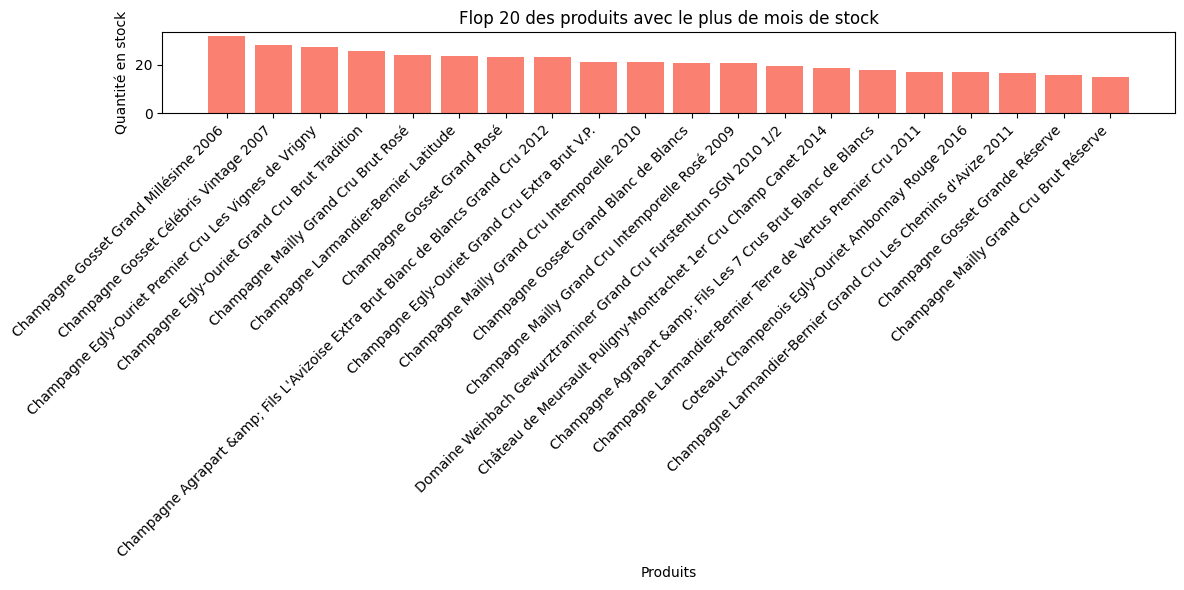

In [ ]:
#Graphique en barre du flop 20 des produits qui ont le plus de mois de stock

# Trier par stock croissant et sélectionner les 20 produits avec le moins de stock
import pandas as pd
import matplotlib.pyplot as plt
flop20 = df_final.sort_values(by='stock_mois', ascending=False).head(20)

# Créer le graphique en barres
plt.figure(figsize=(12,6))
plt.bar(flop20['post_title'], flop20['stock_mois'], color='salmon')

# Ajouter titres et labels
plt.title("Flop 20 des produits avec le plus de mois de stock")
plt.xlabel("Produits")
plt.ylabel("Quantité en stock")

# Rotation des labels pour lisibilité
plt.xticks(rotation=45, ha='right')

# Afficher le graphique
plt.tight_layout()
plt.show()

In [ ]:
#Création de la colonne Valorisation des stocks en euros
df_final['valorisation_stock_euros'] = df_final['stock_quantity'] * df_final['purchase_price']

#Calculer la somme de la colonne "Valorisation_stock_euros"
total_valorisation_stock = df_final['valorisation_stock_euros'].sum()
print(f"La valorisation totale des stocks est de: {total_valorisation_stock:.2f} €")

La valorisation totale des stocks est de: 277350.37 €


In [ ]:
#Calculer la somme de la colonne stock quantity
total_stock_quantity = df_final['stock_quantity'].sum()
print(f"La quantité totale de tous les stocks est de: {total_stock_quantity}")

La quantité totale de tous les stocks est de: 16741


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.4 - Analyse du taux de marge</h3>
</div>

In [ ]:
############################
# Analyse du taux de marge #
############################

#Création de la colonne Prix HT
df_final['prix_ht'] = df_final['price'] / 1.20

#Création de la colonne Taux de marge
df_final['taux_marge'] = (df_final['prix_ht'] - df_final['purchase_price']) / df_final['purchase_price'] * 100

#Afficher le prix minimum de la colonne "taux_marge"
print("Le prix minimum de la colonne 'taux_marge' est:", df_final['taux_marge'].min())

#Afficher le prix maximum de la colonne "taux_marge"
print("Le prix maximum de la colonne 'taux_marge' est:", df_final['taux_marge'].max())


Le prix minimum de la colonne 'taux_marge' est: -86.39433832386852
Le prix maximum de la colonne 'taux_marge' est: 91.41247090530442


In [ ]:
#Affichage de la ligne avec un taux de marge inférieur à 0
df_final[df_final['taux_marge'] < 0]


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_statut,sku,total_sales,tax_status,post_author,product_type,post_title,post_type,sku_length,price_zscore,ca_par_article,part_stock_ca,cumul_part_stock_ca,stock_initial,stock_moyen,stock_mois,valorisation_stock_euros,prix_ht,taux_marge
201,4355,1,12.65,97,instock,77.48,NaN,12589,0.0,taxable,2.0,Champagne,Champagne Egly-Ouriet Grand Cru Blanc de Noirs,product,NaN,-0.707877,0.0,0.0,0.040026,97.0,97.0,0.0,7515.56,10.541667,-86.394338


Il s'agit d'un produit avec une erreur d'affichage de prix, on le constate car il est vendu bien moins cher à nos clients qu'a l'achats auprès de notre fournisseur : Vendu 12.65 € pour un prix d'achat à 77.48€. Heureusement, nous n'en avons pas encore vendus, donc pas de perte suite à l'erreur

In [ ]:
#Création d'un dataframe avec les taux positifs
#Afficher le prix minimum de la colonne "taux_marge"
#Afficher le prix maximum de la colonne "taux_marge"

df_positive_marge = df_final[df_final['taux_marge'] > 0]

print("Le prix minimum de la colonne 'taux_marge' pour les taux positifs est:", df_positive_marge['taux_marge'].min())
print("Le prix maximum de la colonne 'taux_marge' pour les taux positifs est:", df_positive_marge['taux_marge'].max())

#Affichage des deux produits en question
df_positive_marge.loc[df_positive_marge['taux_marge'] == df_positive_marge['taux_marge'].min()]


Le prix minimum de la colonne 'taux_marge' pour les taux positifs est: 29.49782522736259
Le prix maximum de la colonne 'taux_marge' pour les taux positifs est: 91.41247090530442


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_statut,sku,total_sales,tax_status,post_author,product_type,post_title,post_type,sku_length,price_zscore,ca_par_article,part_stock_ca,cumul_part_stock_ca,stock_initial,stock_moyen,stock_mois,valorisation_stock_euros,prix_ht,taux_marge
549,5760,1,13.1,24,instock,8.43,NaN,11258,7.0,taxable,2.0,Huile d'olive,Huile d'Olive Extra Vierge Planeta 50cl,product,NaN,-0.691717,91.7,0.000049,0.032795,31.0,27.5,3.928571,202.32,10.916667,29.497825


In [ ]:
#Affichage du produit avec le plus haut taux de marge
df_positive_marge.loc[df_positive_marge['taux_marge'] == df_positive_marge['taux_marge'].max()]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_statut,sku,total_sales,tax_status,post_author,product_type,post_title,post_type,sku_length,price_zscore,ca_par_article,part_stock_ca,cumul_part_stock_ca,stock_initial,stock_moyen,stock_mois,valorisation_stock_euros,prix_ht,taux_marge
217,4401,1,62.5,5,instock,27.21,NaN,3506,3.0,taxable,2.0,Cognac,Cognac Frapin VSOP,product,NaN,1.082293,187.5,0.000021,0.039532,8.0,6.5,2.166667,136.05,52.083333,91.412471


In [ ]:
#Création d'un dataframe avec le taux de marge moyen par type de produit
moyenne_marge_par_type = df_final.groupby('product_type')['taux_marge'].mean().reset_index()

#Affichage dans un graphique du taux de marge par type de produit
fig_marge_par_type = px.bar(
    moyenne_marge_par_type,
    x='product_type',
    y='taux_marge',
    title='Taux de Marge Moyen par Type de Produit',
    labels={'product_type': 'Type de Produit', 'taux_marge': 'Taux de Marge Moyen (%)'},
    hover_data=['taux_marge']
)
fig_marge_par_type.update_layout(xaxis={'categoryorder':'total descending'})
fig_marge_par_type.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.5 - Analyse des corrélations entre les variables stock, sales et price</h3>
</div>

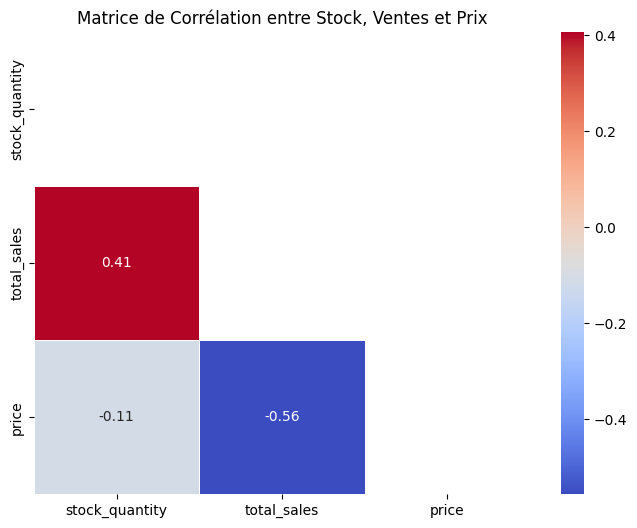

In [ ]:
#Importation de Seaborn et Matplotlib
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Sélection des variables d'intérêt
correlation_data = df_final[['stock_quantity', 'total_sales', 'price']]

# Calcul de la matrice de corrélation
correlation_matrix = correlation_data.corr()

# Création d'un mask pour n'afficher qu'une demi heatmap
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Création de la heatmap de corrélation
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matrice de Corrélation entre Stock, Ventes et Prix')
plt.show()

**Que peut-on conclure des corrélations ?**

Nous remarquons 3 choses

*   Pour ceux qui est du stock et des ventes (+0.44), la correlation est moyenne, plus les ventes sont élever plus le stock augmente. Ce qui suggère une bonne gestion de la rotation de celui-ci pour répondre à la demande

*   Pour la correclation entre stock et prix, la correlation est infime (-0.11), mais ont peut dire que plus un produit est cher, moins il y en a en stock

* Enfin pour les ventes et le prix (-0.52), c'est une forte correlation négative, elle se traduit par les faits que plus les produits seront cher, moins ceux ci seront vendus




# Pour ce qui est des ventes sur internet ?

In [ ]:
#Afficher le nombre de produits vendus sur le site internet (onsale_web) et ceux n'ont vendus sur internet
df_final.groupby('onsale_web')['total_sales'].sum().reset_index()

,onsale_web,total_sales
0,0,14.0
1,1,5737.0


In [ ]:
#Affichier les 14 produits n'ont vendus sur le site
df_final.loc[df_final['onsale_web'] == 0].head(14)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_statut,sku,total_sales,tax_status,post_author,product_type,post_title,post_type,sku_length,price_zscore,ca_par_article,part_stock_ca,cumul_part_stock_ca,stock_initial,stock_moyen,stock_mois,valorisation_stock_euros,prix_ht,taux_marge
119,4200,0,5.8,33,instock,3.12,NaN,16295,14.0,taxable,2.0,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...,product,NaN,-0.953869,81.2,0.000097,0.005004,47.0,40.0,2.857143,102.96,4.833333,54.91453


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.6 - Mise à disposition de la nouvelle table sur un fichier Excel</h3>
</div>

In [ ]:
#Mettre le dataset df_merge sur un fichier Excel
#Cette étape peut être utile pour partager le résultat du dataset obtenu avec les équipes.
#output_path = '/content/drive/MyDrive/Projet_6_Data/df_final.xlsx'
#df_final.to_excel(output_path, index=False)
#"print(f"Le dataset df_final a été sauvegardé dans '{output_path}'")